# Un pico sobre o fondo

### Boletín II, exercicio 5 (guiado): $H \to Z + Z^* \to 4$ leptóns cos datos abertos de CMS

Jose A. Hernando

*Departamento de Física de Partículas. Universidade de Santiago de Compostela*

In [1]:
# Configuración e importacións
%matplotlib inline

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import poisson, norm

# Os datos están en datos/, xunto a este caderno; se non (Google Colab), lense de GitHub
URL = 'https://raw.githubusercontent.com/xabiercidvidal/USC-FNeP/main/notebooks/bols/datos/'

def lee(nombre):
    try:
        return pd.read_csv('datos/' + nombre, comment='#')
    except FileNotFoundError:
        return pd.read_csv(URL + nombre, comment='#')

# Cores Okabe-Ito (lexibles con daltonismo), e ademais tramas distintas
COL = {'zz': '#56B4E9', 'z_x': '#E69F00', 'ttbar': '#999999', 'higgs': '#D55E00'}

## Obxectivos

* Calcular a **masa invariante** de catro leptóns a partir dos seus cuadrimomentos medidos.

* Reconstruír os dous bosóns intermedios, $Z$ e $Z^*$, emparellando os leptóns.

* Construír o espectro de $m_{4l}$ e comparalo co que se **espera do fondo**.

* Contar o exceso e estimar a súa **significancia** coa distribución de Poisson.

É a versión «de verdade» do exercicio 4: alí líase a gráfica de ATLAS; aquí faina ti cos
sucesos de CMS.

## Os datos

CMS publica parte dos seus datos no [CERN Open Data Portal](https://opendata.cern.ch). Usamos os
sucesos con **catro leptóns illados** (dous pares de carga oposta e mesmo sabor: $4\mu$, $4e$ ou
$2e2\mu$) de 2011 ($\sqrt s = 7$ TeV, 2.3 $\mathrm{fb}^{-1}$) e 2012 ($\sqrt s = 8$ TeV, 11.6 $\mathrm{fb}^{-1}$),
seleccionados polo exemplo de análise de CMS [Jomhari, Geiser e Bin Anuar,
[DOI:10.7483/OPENDATA.CMS.JKB8.RR42](https://doi.org/10.7483/OPENDATA.CMS.JKB8.RR42)].

Cada fila é un suceso. Para cada leptón $i = 1, \dots, 4$: `PIDi` (11 electrón, 13 muón; negativo,
antipartícula), `Ei`, `pxi`, `pyi`, `pzi` (GeV) e `Qi` (carga). As últimas columnas, `mZ1`, `mZ2` e
`M`, son o resultado da análise de CMS: usarémolas só para comprobar a nosa.

O ficheiro `higgs_4l_cms_esperados.csv` dá, por intervalos de 3 GeV de $m_{4l}$, os sucesos que se
esperan de cada proceso segundo a simulación, xa normalizados á luminosidade dos datos.

## A masa invariante de catro leptóns

<div class="admonition tip">
<p class="admonition-title"><b>[>] Tarefa — Os datos e a masa invariante</b></p>

1. Le `higgs_4l_cms.csv`. Cantos sucesos hai de cada ano e de cada canle?
2. Escribe unha función que calcule a masa invariante dun conxunto de partículas a partir dos seus
   cuadrimomentos, $m^2 = \left(\sum E_i\right)^2 - \left|\sum \vec p_i\right|^2$.
3. Calcula $m_{4l}$ para todos os sucesos e compáraa coa columna `M`.
4. Pódese desprezar a masa dos leptóns? Compróbao con $E^2 - p^2$ de cada leptón.

</div>

In [2]:
datos = lee('higgs_4l_cms.csv')
print('sucesos:', len(datos))
print(datos.groupby(['periodo', 'canal']).size())

def cuadrimomento(df, i):
    # (E, px, py, pz) do leptón i, unha fila por suceso
    return df[['E{}'.format(i), 'px{}'.format(i), 'py{}'.format(i), 'pz{}'.format(i)]].to_numpy()

def masa_invariante(*ps):
    p = sum(ps)
    m2 = p[:, 0]**2 - np.sum(p[:, 1:]**2, axis=1)
    return np.sqrt(np.clip(m2, 0, None))

leps = [cuadrimomento(datos, i) for i in range(1, 5)]
m4l  = masa_invariante(*leps)

print('máxima diferenza con M       = {:.3f} GeV'.format(np.max(np.abs(m4l - datos['M']))))
m2_lep = np.concatenate([l[:, 0]**2 - np.sum(l[:, 1:]**2, axis=1) for l in leps])
print('E^2 - p^2 dos leptóns        : entre {:.2f} e {:.2f} GeV^2'.format(m2_lep.min(), m2_lep.max()))

sucesos: 278
periodo  canal
2011     2e2mu     13
         4e         7
         4mu       18
2012     2e2mu    104
         4e        41
         4mu       95
dtype: int64
máxima diferenza con M       = 0.006 GeV
E^2 - p^2 dos leptóns        : entre -0.41 e 0.88 GeV^2


<details>
<summary><b>Solución</b></summary>

1. 278 sucesos: 38 de 2011 (18 $4\mu$, 7 $4e$, 13 $2e2\mu$) e 240 de 2012 (95, 41, 104). Hai menos $4e$
   ca $4\mu$: os electróns identifícanse con menos eficiencia (e con máis fondo) ca os muóns.
2. e 3. A $m_{4l}$ calculada coincide con `M` en menos de 0.01 GeV (redondeo do ficheiro).
4. $E^2 - p^2$ sae entre $-0.4$ e $0.9$ $\mathrm{GeV}^2$, dos dous signos: é o redondeo do ficheiro
   (enerxías de ata centos de GeV con tres ou catro cifras decimais), non unha masa.
   Con $m_\mu^2 = 0.011$ $\mathrm{GeV}^2$ e $m_e^2 = 2.6\times10^{-7}$ $\mathrm{GeV}^2$, a masa dos leptóns non se ve:
   pódese desprezar.

</details>

## Os dous bosóns intermedios

Se os catro leptóns veñen de $H \to Z + Z^*$, cada bosón dá un par de **carga oposta e mesmo
sabor**: $e + e^+$ ou $\mu + \mu^+$. Nas canles $4e$ e $4\mu$ hai dous emparellamentos posibles.

Convenio de CMS: $Z_1$ é o par cuxa masa está máis preto de $m_Z = 91.19$ GeV; $Z_2$, o outro.

<div class="admonition tip">
<p class="admonition-title"><b>[>] Tarefa — O Z e o Z*</b></p>

1. Para cada suceso, forma os emparellamentos posibles con pares de carga oposta e mesmo sabor
   (usa o `PID`: un par vale se `PIDa == -PIDb`), e quédate co que dá o $Z_1$ máis próximo a $m_Z$.
   Comproba os teus $m_{Z_1}$ e $m_{Z_2}$ coas columnas `mZ1` e `mZ2`.
2. Debuxa $m_{Z_1}$ e $m_{Z_2}$ para todos os sucesos e para os que teñen $121 < m_{4l} < 130$ GeV.
3. Por que nesa xanela $m_{Z_2}$ é sempre pequena? Que relación hai entre $m_{Z_1}$, $m_{Z_2}$ e $m_{4l}$?

</div>

coinciden con mZ1, mZ2 de CMS: 100%, 100%


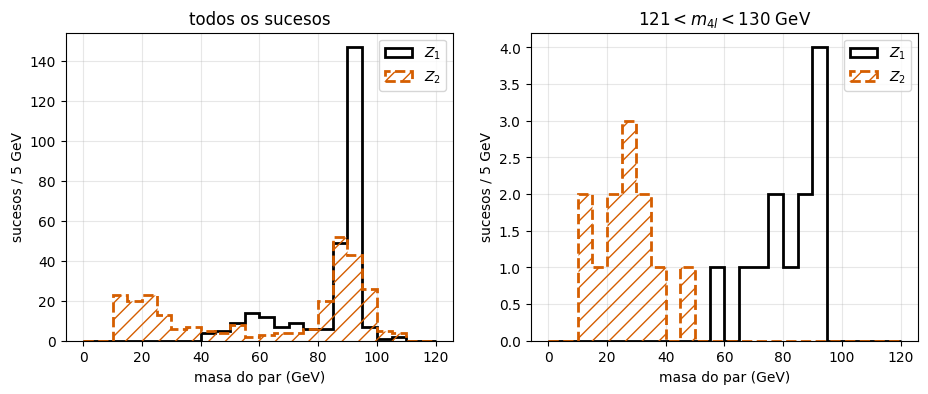

na xanela: mZ2 máxima = 45.7 GeV; mZ1 + mZ2 <= m4l en todos os sucesos: True


In [3]:
MZ  = 91.19
pid = [datos['PID{}'.format(i)].to_numpy() for i in range(1, 5)]

mZ1 = np.full(len(datos), np.nan)
mZ2 = np.full(len(datos), np.nan)
for (a, b), (c, d) in [((0, 1), (2, 3)), ((0, 2), (1, 3)), ((0, 3), (1, 2))]:
    valido = (pid[a] == -pid[b]) & (pid[c] == -pid[d])
    mab, mcd = masa_invariante(leps[a], leps[b]), masa_invariante(leps[c], leps[d])
    z1 = np.where(np.abs(mab - MZ) < np.abs(mcd - MZ), mab, mcd)
    z2 = np.where(np.abs(mab - MZ) < np.abs(mcd - MZ), mcd, mab)
    mejor = valido & (np.isnan(mZ1) | (np.abs(z1 - MZ) < np.abs(mZ1 - MZ)))
    mZ1[mejor], mZ2[mejor] = z1[mejor], z2[mejor]

print('coinciden con mZ1, mZ2 de CMS: {:.0%}, {:.0%}'.format(
      np.mean(np.abs(mZ1 - datos['mZ1']) < 0.05), np.mean(np.abs(mZ2 - datos['mZ2']) < 0.05)))

ventana = (m4l > 121) & (m4l < 130)
fig, axs = plt.subplots(1, 2, figsize=(11, 4))
for ax, sel, titulo in zip(axs, (np.ones(len(datos), bool), ventana),
                           ('todos os sucesos', r'$121 < m_{4l} < 130$ GeV')):
    ax.hist(mZ1[sel], bins=np.arange(0, 121, 5), histtype='step', lw=2, color='k', label=r'$Z_1$')
    ax.hist(mZ2[sel], bins=np.arange(0, 121, 5), histtype='step', lw=2, ls='--', color=COL['higgs'],
            hatch='//', label=r'$Z_2$')
    ax.set_xlabel('masa do par (GeV)'); ax.set_title(titulo); ax.grid(alpha=0.3); ax.legend()
for ax in axs:
    ax.set_ylabel('sucesos / 5 GeV')
plt.show()
print('na xanela: mZ2 máxima = {:.1f} GeV; mZ1 + mZ2 <= m4l en todos os sucesos: {}'.format(
      mZ2[ventana].max(), np.all(mZ1 + mZ2 <= m4l + 1e-6)))

<details>
<summary><b>Solución</b></summary>

1. O emparellamento reproduce o de CMS no 100 % dos sucesos.
2. No conxunto, $m_{Z_1}$ ten un pico en $m_Z$ (case sempre hai un $Z$ real) e $m_{Z_2}$ esténdese
   ata máis de 100 GeV (os $ZZ$ do fondo, cos dous $Z$ reais). Na xanela do Higgs, $m_{Z_2}$
   non pasa duns 45 GeV e a maioría está entre 15 e 35 GeV.
3. No sistema de repouso dos catro leptóns, cada par ten $E_i \ge m_{Z_i}$ e
   $m_{4l} = E_1 + E_2 \ge m_{Z_1} + m_{Z_2}$ (a igualdade, se os dous pares están en repouso). Con
   $m_{4l} \simeq 125$ GeV e $m_{Z_1} \simeq 91$ GeV, $m_{Z_2} \lesssim 34$ GeV: o segundo $Z$ é
   **virtual**, como no exercicio 4. Cando o $Z_1$ tampouco está na súa masa (hai sucesos con
   $m_{Z_1} \sim 60$–$75$ GeV), o $Z_2$ pode ser algo maior.

</details>

## O espectro de $m_{4l}$

<div class="admonition tip">
<p class="admonition-title"><b>[>] Tarefa — Datos fronte ao esperado</b></p>

1. Le `higgs_4l_cms_esperados.csv` e fai o histograma das túas $m_{4l}$ cos mesmos intervalos
   (de 70 a 181 GeV, de 3 GeV). Pon a cada punto o seu erro, $\sqrt{N}$.
2. Empila os tres fondos ($ZZ$, $Z/\gamma^*$ + X, $t\bar t$) e superpón os datos. Onde está o pico
   que explica o fondo? De que é?
3. Onde hai sucesos que o fondo non explica? Engade o sinal esperado dun Higgs de 125 GeV.

</div>

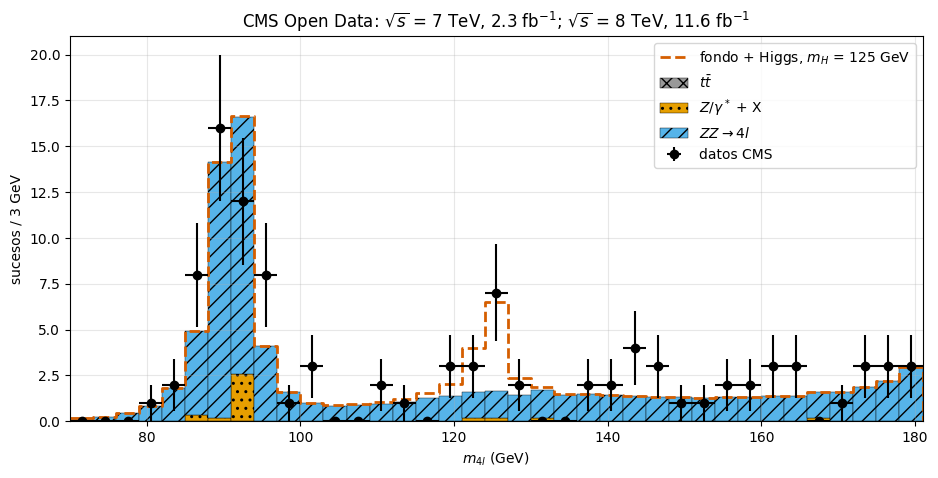

sucesos entre 70 e 181 GeV: 102 datos, 84.0 de fondo, 9.7 de sinal


In [4]:
esperados = lee('higgs_4l_cms_esperados.csv')
bordes = np.append(esperados['m_min'], esperados['m_max'].iloc[-1])
centro = 0.5 * (bordes[:-1] + bordes[1:])
n, _   = np.histogram(m4l, bins=bordes)

fig, ax = plt.subplots(figsize=(11, 5))
abajo = np.zeros(len(centro))
for col, etiqueta, trama in (('ttbar', r'$t\bar t$', 'xx'), ('z_x', r'$Z/\gamma^*$ + X', '..'),
                             ('zz', r'$ZZ \to 4l$', '//')):
    ax.bar(centro, esperados[col], width=3, bottom=abajo, color=COL[col], hatch=trama,
           edgecolor='k', lw=0.3, label=etiqueta)
    abajo = abajo + esperados[col].to_numpy()
fondo = abajo.copy()
ax.step(bordes, np.append(fondo + esperados['higgs_125'], 0), where='post', color=COL['higgs'],
        lw=2, ls='--', label=r'fondo + Higgs, $m_H$ = 125 GeV')
ax.errorbar(centro, n, yerr=np.sqrt(n), xerr=1.5, fmt='o', color='k', label='datos CMS')
ax.set_xlabel(r'$m_{4l}$ (GeV)'); ax.set_ylabel('sucesos / 3 GeV')
ax.set_title(r'CMS Open Data: $\sqrt{s}$ = 7 TeV, 2.3 fb$^{-1}$; $\sqrt{s}$ = 8 TeV, 11.6 fb$^{-1}$')
ax.set_xlim(70, 181); ax.grid(alpha=0.3); ax.legend()
plt.show()

print('sucesos entre 70 e 181 GeV: {} datos, {:.1f} de fondo, {:.1f} de sinal'.format(
      n.sum(), fondo.sum(), esperados['higgs_125'].sum()))

<details>
<summary><b>Solución</b></summary>

1. e 2. O fondo ten un pico en **91 GeV**: é o propio $Z$ desintegrándose en catro leptóns,
   $Z \to \ell + \ell^+ + \gamma^* \to 4\ell$ (un leptón do par radia un fotón virtual que dá outro par).
   Os datos séguenno ben: serve de calibración da escala de masas. Cara a 180 GeV empeza a subir o
   $ZZ$ cos dous $Z$ reais (limiar en $2m_Z = 182$ GeV).
3. Hai un exceso de sucesos entre 121 e 130 GeV, xusto onde cae o sinal esperado dun Higgs de
   125 GeV. No resto, datos e fondo casan dentro das flutuacións $\sqrt N$. A anchura do
   pico, duns poucos GeV, é a resolución do detector; a do Higgs é de 4 MeV.

</details>

## Canto de raro é o exceso?

Se só houbese fondo, o número de sucesos na xanela seguiría unha **Poisson** de media $b$, o
fondo esperado. O exceso é significativo se é moi improbable que o fondo só dea tantos sucesos
**ou máis**: esa probabilidade é o **valor $p$**.

Adóitase traducir a «sigmas», $Z$: a distancia á media dunha gaussiana que deixa fóra a mesma
probabilidade por un lado. En física de partículas, $Z = 3$ ($p = 1.3\times10^{-3}$) é un **indicio**
e $Z = 5$ ($p = 2.9\times10^{-7}$), un **descubrimento**.

<div class="admonition tip">
<p class="admonition-title"><b>[>] Tarefa — A significancia</b></p>

1. Conta os sucesos observados $n$, o fondo $b$ e o sinal esperado $s$ na xanela
   $121 < m_{4l} < 130$ GeV (os intervalos 121–124, 124–127 e 127–130).
2. Calcula o valor $p$ coa Poisson, $P(N \ge n \,|\, b)$, e compróbao **simulando** un millón de
   experimentos nos que só hai fondo. A cantas sigmas corresponde?
3. É un descubrimento? Estima, con $Z \simeq s/\sqrt{b}$, que luminosidade faría falta para chegar a
   $5\sigma$.
4. Compara coa figura de ATLAS do exercicio 4 (29 $\mathrm{fb}^{-1}$ a 13.6 TeV).

</div>

xanela 121-130 GeV: n = 12, b = 4.66, s = 8.20
p (Poisson)    = 3.1e-03   ->  Z = 2.7
p (simulación) = 3.2e-03
s/sqrt(b) = 3.8;  luminosidade para 5 sigma: x1.7 = 24 fb-1


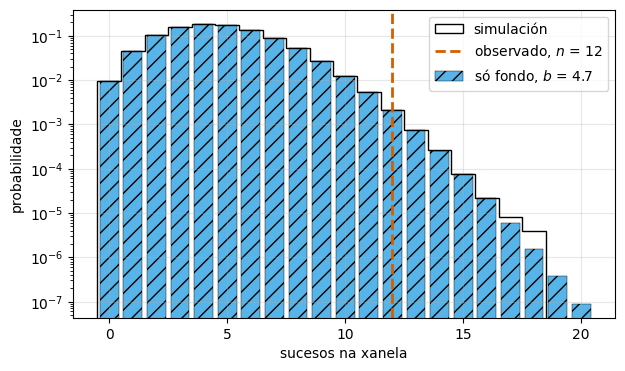

In [5]:
en_ventana = (bordes[:-1] >= 121) & (bordes[1:] <= 130)
n_obs = n[en_ventana].sum()
b     = fondo[en_ventana].sum()
s     = esperados['higgs_125'].to_numpy()[en_ventana].sum()
print('xanela 121-130 GeV: n = {}, b = {:.2f}, s = {:.2f}'.format(n_obs, b, s))

p = poisson.sf(n_obs - 1, b)                         # P(N >= n_obs | b)
rng   = np.random.default_rng(1)
toys  = rng.poisson(b, size=10**6)                    # un millón de experimentos só con fondo
p_toy = np.mean(toys >= n_obs)
print('p (Poisson)    = {:.1e}   ->  Z = {:.1f}'.format(p, norm.isf(p)))
print('p (simulación) = {:.1e}'.format(p_toy))

Z_aprox = s / np.sqrt(b)
print('s/sqrt(b) = {:.1f};  luminosidade para 5 sigma: x{:.1f} = {:.0f} fb-1'.format(
      Z_aprox, (5 / Z_aprox)**2, (5 / Z_aprox)**2 * (2.3 + 11.6)))

fig, ax = plt.subplots(figsize=(7, 4))
ks = np.arange(0, 21)
ax.bar(ks, poisson.pmf(ks, b), color=COL['zz'], hatch='//', edgecolor='k', lw=0.3,
       label=r'só fondo, $b$ = {:.1f}'.format(b))
ax.hist(toys, bins=ks - 0.5, density=True, histtype='step', color='k', label='simulación')
ax.axvline(n_obs, color=COL['higgs'], ls='--', lw=2, label=r'observado, $n$ = {}'.format(n_obs))
ax.set_xlabel('sucesos na xanela'); ax.set_ylabel('probabilidade'); ax.set_yscale('log')
ax.grid(alpha=0.3); ax.legend()
plt.show()

<details>
<summary><b>Solución</b></summary>

1. $n = 12$, $b = 4.7$ e $s = 8.2$: esperábanse $b + s \simeq 13$ se o Higgs existe, e vense 12.
2. $P(N \ge 12 \,|\, 4.7) = 3.1\times10^{-3}$ (a simulación dá o mesmo), é dicir,
   $Z \simeq 2.7\sigma$: un **indicio**, non un descubrimento.
3. $s/\sqrt b = 3.8$ (a aproximación gaussiana esaxera con tan poucos sucesos: a Poisson dá menos).
   Como $s$ e $b$ medran coa luminosidade $L$, $Z \propto \sqrt L$: para $5\sigma$ fai falta
   $(5/3.8)^2 \simeq 1.7$ veces máis, uns 24 $\mathrm{fb}^{-1}$, e algo máis coa Poisson. Por iso en xullo de
   2012 CMS e ATLAS combinaron varias canles ($\gamma\gamma$ e $4\ell$): ningunha chegaba soa a $5\sigma$.
   Neste caderno úsase, ademais, unha fracción dos datos e unha selección sinxela.
4. ATLAS, con 29 $\mathrm{fb}^{-1}$ a 13.6 TeV, ve uns 30 sucesos de exceso sobre $\simeq 17$ de fondo na mesma
   xanela. Hai o dobre de luminosidade e a sección eficaz de produción do Higgs é unhas 2.7 veces
   maior a 13.6 TeV ca a 8 TeV: o pico vese por si só a simple vista.

</details>

## Resumo

* A masa invariante dos catro leptóns, $m_{4l}^2 = (\sum E)^2 - |\sum \vec p|^2$, é a masa da
  partícula nai, sexa cal sexa o seu movemento no laboratorio.

* Os leptóns emparéllanse en dous $Z$: un preto da súa masa e outro, $Z^*$, virtual, porque
  $m_H < 2 m_Z$.

* O fondo ($ZZ$, $Z$ + X, $t\bar t$) explica o pico do $Z$ en 91 GeV; en 121–130 GeV hai 12 sucesos
  onde o fondo dá 4.7.

* Coa Poisson, $p = 3\times10^{-3}$: $2.7\sigma$, un indicio. O descubrimento ($5\sigma$) pide máis
  luminosidade ou combinar canles.